# Semantic Loans — Bluesky Corpus

Análise de semantic loans do inglês no português brasileiro a partir de posts do Bluesky (2023+).

**Seções:**
1. Upload e carregamento dos CSVs
2. Visão geral do corpus
3. Proporção calque/nativo por termo
4. Distribuição por ano
5. Comparação entre termos — quais estão mais avançados

In [1]:
# ── 0. Dependências ───────────────────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from google.colab import files

pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_rows', 100)

# Paleta consistente
COR_CALQUE = '#d95f02'
COR_NATIVO = '#1b9e77'
CORES      = {'calque': COR_CALQUE, 'nativo': COR_NATIVO}

print('Pronto.')

Pronto.


In [18]:
# ── 1. Upload dos CSVs ────────────────────────────────────────────────────────
# Faça upload de todos os CSVs gerados pelo bluesky_collector.py
# (apply_bluesky.csv, realize_bluesky.csv, etc.)

uploaded = files.upload()
print('Arquivos carregados:', list(uploaded.keys()))

Saving address_bluesky.csv to address_bluesky.csv
Arquivos carregados: ['address_bluesky.csv']


In [19]:
# ── 2. Carregamento e consolidação ────────────────────────────────────────────

dfs = []
for filename in uploaded.keys():
    df = pd.read_csv(filename)
    dfs.append(df)

dados = pd.concat(dfs, ignore_index=True)
dados['ano'] = pd.to_numeric(dados['ano'], errors='coerce').astype('Int64')

# remove duplicatas por uri (mesmo post em queries diferentes)
dados = dados.drop_duplicates(subset='uri')

print(f'Total de posts únicos: {len(dados)}')
print(f'Período: {dados.ano.min()} – {dados.ano.max()}')
print(f'Termos: {sorted(dados.termo.unique())}')
print()
print('Por termo e tipo:')
print(dados.groupby(['termo', 'tipo']).size().unstack(fill_value=0))

Total de posts únicos: 2137
Período: 2023 – 2026
Termos: ['address']

Por termo e tipo:
tipo     calque  nativo
termo                  
address      73    2064


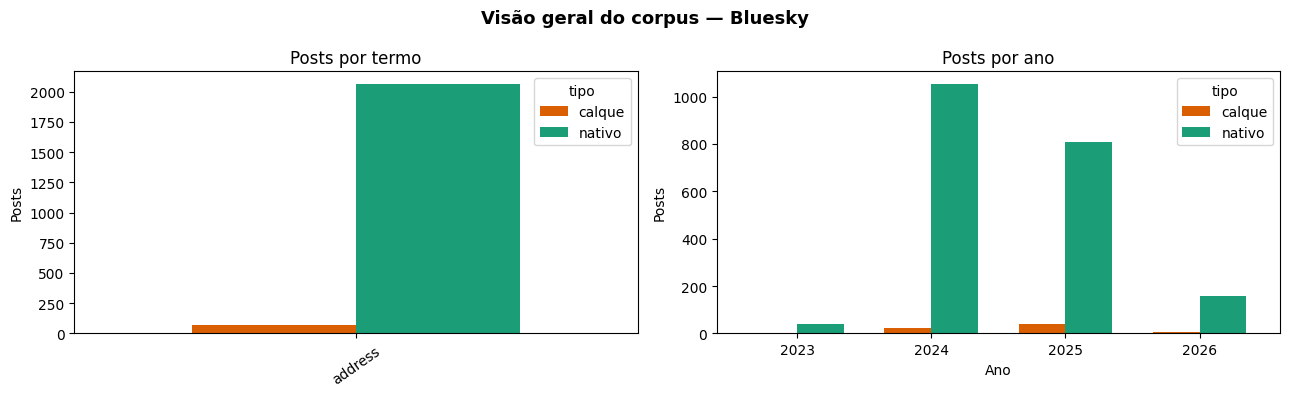

In [20]:
# ── 3. Visão geral do corpus ──────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Visão geral do corpus — Bluesky', fontsize=13, fontweight='bold')

# posts por termo
por_termo = dados.groupby(['termo', 'tipo']).size().unstack(fill_value=0)
cores_barras = [CORES.get(c, '#999') for c in por_termo.columns]
por_termo.plot(kind='bar', ax=axes[0], color=cores_barras, width=0.7)
axes[0].set_title('Posts por termo')
axes[0].set_xlabel('')
axes[0].set_ylabel('Posts')
axes[0].tick_params(axis='x', rotation=35)
axes[0].legend(title='tipo')

# posts por ano
por_ano = dados.groupby(['ano', 'tipo']).size().unstack(fill_value=0).sort_index()
cores_ano = [CORES.get(c, '#999') for c in por_ano.columns]
por_ano.plot(kind='bar', ax=axes[1], color=cores_ano, width=0.7)
axes[1].set_title('Posts por ano')
axes[1].set_xlabel('Ano')
axes[1].set_ylabel('Posts')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='tipo')

plt.tight_layout()
plt.savefig('bluesky_visao_geral.png', dpi=150, bbox_inches='tight')
plt.show()

Proporção calque/nativo por termo:
tipo     calque  nativo  total  pct_calque
termo                                     
address      73    2064   2137         3.4



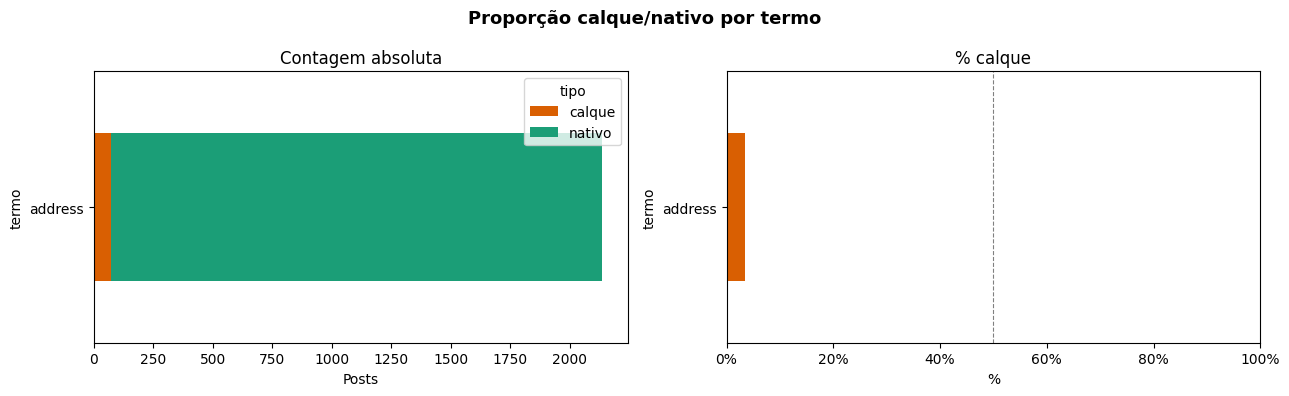

In [21]:
# ── 4. Proporção calque/nativo por termo ──────────────────────────────────────

resumo = dados.groupby(['termo', 'tipo']).size().unstack(fill_value=0)

if 'calque' not in resumo.columns:
    resumo['calque'] = 0
if 'nativo' not in resumo.columns:
    resumo['nativo'] = 0

resumo['total']      = resumo['calque'] + resumo['nativo']
resumo['pct_calque'] = (resumo['calque'] / resumo['total'] * 100).round(1)
resumo = resumo.sort_values('pct_calque', ascending=False)

print('Proporção calque/nativo por termo:')
print(resumo[['calque', 'nativo', 'total', 'pct_calque']].to_string())
print()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Proporção calque/nativo por termo', fontsize=13, fontweight='bold')

# barras empilhadas absolutas
resumo[['calque', 'nativo']].plot(
    kind='barh', ax=axes[0],
    color=[COR_CALQUE, COR_NATIVO],
    stacked=True, width=0.6
)
axes[0].set_title('Contagem absoluta')
axes[0].set_xlabel('Posts')
axes[0].legend(title='tipo')

# % calque
resumo['pct_calque'].plot(
    kind='barh', ax=axes[1],
    color=COR_CALQUE, width=0.6
)
axes[1].set_title('% calque')
axes[1].set_xlabel('%')
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter())
axes[1].set_xlim(0, 100)
axes[1].axvline(50, color='gray', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.savefig('bluesky_proporcao_termos.png', dpi=150, bbox_inches='tight')
plt.show()

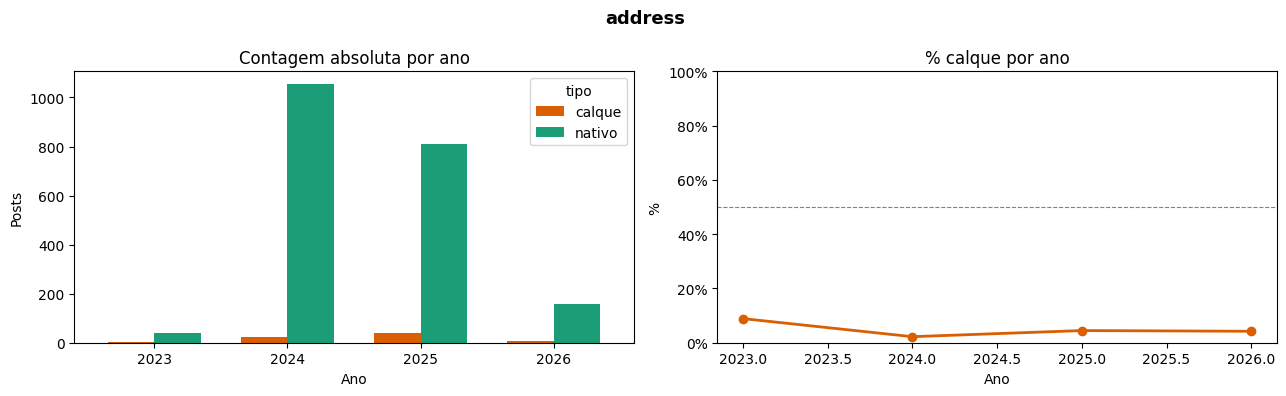

tipo  calque  nativo  total  pct_calque
ano                                    
2023       4      41     45         8.9
2024      24    1054   1078         2.2
2025      38     810    848         4.5
2026       7     159    166         4.2



In [22]:
# ── 5. Proporção calque/nativo por termo por ano ───────────────────────────────
# Um gráfico por termo: contagem absoluta + % calque ao longo dos anos

termos = sorted(dados['termo'].unique())

for termo in termos:
    subset = dados[dados['termo'] == termo].dropna(subset=['ano'])
    if subset.empty:
        continue

    por_ano = (
        subset.groupby(['ano', 'tipo'])
        .size().unstack(fill_value=0).sort_index()
    )

    if 'calque' not in por_ano.columns:
        por_ano['calque'] = 0
    if 'nativo' not in por_ano.columns:
        por_ano['nativo'] = 0

    por_ano['total']      = por_ano['calque'] + por_ano['nativo']
    por_ano['pct_calque'] = por_ano.apply(
        lambda r: r['calque'] / r['total'] * 100 if r['total'] > 0 else np.nan,
        axis=1
    )

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f'{termo}', fontsize=13, fontweight='bold')

    # contagem absoluta
    por_ano[['calque', 'nativo']].plot(
        kind='bar', ax=axes[0],
        color=[COR_CALQUE, COR_NATIVO], width=0.7
    )
    axes[0].set_title('Contagem absoluta por ano')
    axes[0].set_xlabel('Ano')
    axes[0].set_ylabel('Posts')
    axes[0].tick_params(axis='x', rotation=0)
    axes[0].legend(title='tipo')

    # % calque
    por_ano['pct_calque'].plot(
        kind='line', ax=axes[1],
        marker='o', color=COR_CALQUE, linewidth=2
    )
    axes[1].set_title('% calque por ano')
    axes[1].set_xlabel('Ano')
    axes[1].set_ylabel('%')
    axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
    axes[1].set_ylim(0, 100)
    axes[1].axhline(50, color='gray', linestyle='--', linewidth=0.8)

    plt.tight_layout()
    plt.savefig(f'{termo}_bluesky_diacronico.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(por_ano[['calque', 'nativo', 'total', 'pct_calque']].round(1))
    print()

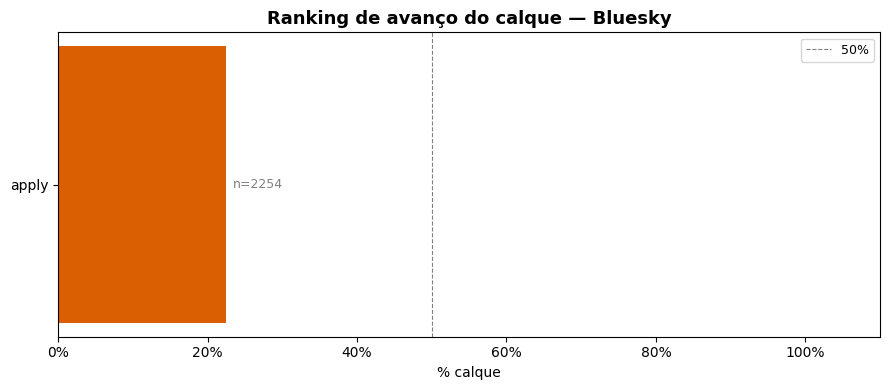

Resumo final:
tipo   calque  nativo  total  pct_calque
termo                                   
apply     506    1748   2254        22.4


In [9]:
# ── 6. Comparação entre termos — ranking de avanço do calque ─────────────────
# Mostra quais semantic loans estão mais consolidados no Bluesky.
# Ordena por % calque e inclui volume para contextualizar.

resumo_ord = resumo.sort_values('pct_calque', ascending=True)

fig, ax = plt.subplots(figsize=(9, max(4, len(resumo_ord) * 0.6)))

bars = ax.barh(
    resumo_ord.index,
    resumo_ord['pct_calque'],
    color=COR_CALQUE, height=0.5
)

# anota total de posts em cada barra
for bar, (_, row) in zip(bars, resumo_ord.iterrows()):
    ax.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height() / 2,
        f"n={int(row['total'])}",
        va='center', fontsize=9, color='gray'
    )

ax.set_title('Ranking de avanço do calque — Bluesky', fontsize=13, fontweight='bold')
ax.set_xlabel('% calque')
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_xlim(0, 110)
ax.axvline(50, color='gray', linestyle='--', linewidth=0.8, label='50%')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('bluesky_ranking_calques.png', dpi=150, bbox_inches='tight')
plt.show()

print('Resumo final:')
print(resumo_ord[['calque', 'nativo', 'total', 'pct_calque']]
      .sort_values('pct_calque', ascending=False).to_string())

In [ ]:
# ── 7. Export ─────────────────────────────────────────────────────────────────
dados.to_csv('bluesky_consolidado.csv', index=False)
files.download('bluesky_consolidado.csv')
print(f'Exportado: bluesky_consolidado.csv ({len(dados)} posts)')